# TP2 - Ejercicio 1: El entrenamiento de Naruto Uzumaki
## Que pide y como se resuelve

Naruto usa su Jutsu Multi Clones de Sombra: se crean **N clones**, y cada clon tiene que ser un **hilo real** (`std::thread`). No se puede usar ningun mecanismo de comunicacion ni sincronizacion entre hilos (nada de mutex, condition_variable, etc).

Cada clon tiene una cantidad aleatoria de Chakra (5 a 10 unidades). Gasta cada unidad de Chakra en un intento de entrenamiento (100 a 200 ms), con 50% de probabilidad de subir un nivel. Al agotar el Chakra, el clon desaparece (termina el hilo). Al final, Naruto incorpora como propio el nivel alcanzado por todos los clones (se suman).

**Como se evita la sincronizacion:** antes de crear ningun hilo, el hilo principal genera una semilla aleatoria por clon (de forma secuencial). Cada clon usa su propio generador (`std::mt19937`) y escribe unicamente su propia posicion de un `vector<int>` de resultados ya reservado con su tamano final — como nunca dos hilos escriben la misma posicion, no hace falta ningun lock. La creacion es concurrente: se lanzan los N hilos en un bucle, y recien despues se espera a cada uno con `join()` en otro bucle.

## Programa

In [1]:
%%writefile naruto_training.cpp

#include <chrono>
#include <cstdlib>
#include <iostream>
#include <random>
#include <thread>
#include <vector>

namespace
{
    constexpr int MIN_CHAKRA = 5;
    constexpr int MAX_CHAKRA = 10;
    constexpr int MIN_ATTEMPT_MS = 100;
    constexpr int MAX_ATTEMPT_MS = 200;
    constexpr double LEVEL_UP_PROBABILITY = 0.5;
}


void trainClone(int cloneId, unsigned int seed, int &levelOut)
{
    std::mt19937 rng(seed);
    std::uniform_int_distribution<int> chakraDist(MIN_CHAKRA, MAX_CHAKRA);
    std::uniform_int_distribution<int> attemptDurationDist(MIN_ATTEMPT_MS, MAX_ATTEMPT_MS);
    std::uniform_real_distribution<double> successDist(0.0, 1.0);

    int chakra = chakraDist(rng);
    int level = 0;

    for (int attempt = 0; attempt < chakra; ++attempt)
    {
        std::this_thread::sleep_for(std::chrono::milliseconds(attemptDurationDist(rng)));

        if (successDist(rng) < LEVEL_UP_PROBABILITY)
        {
            ++level;
        }
    }

    levelOut = level;
    (void)cloneId;
}

int main(int argc, char *argv[])
{
    int numClones = 10;
    if (argc > 1)
    {
        numClones = std::atoi(argv[1]);
    }
    if (numClones <= 0)
    {
        std::cerr << "La cantidad de clones debe ser un entero positivo." << std::endl;
        return 1;
    }

    std::random_device rd;
    std::mt19937 seedGenerator(rd());
    std::vector<unsigned int> seeds(numClones);
    for (int i = 0; i < numClones; ++i)
    {
        seeds[i] = seedGenerator();
    }

    std::vector<int> levels(numClones, 0);
    std::vector<std::thread> clones;
    clones.reserve(numClones);

    auto start = std::chrono::steady_clock::now();

    for (int i = 0; i < numClones; ++i)
    {
        clones.emplace_back(trainClone, i, seeds[i], std::ref(levels[i]));
    }

    for (auto &clone : clones)
    {
        clone.join();
    }

    auto end = std::chrono::steady_clock::now();
    auto elapsedMs = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();

    int totalLevel = 0;
    for (int i = 0; i < numClones; ++i)
    {
        std::cout << "Clon " << i << ": nivel alcanzado = " << levels[i] << std::endl;
        totalLevel += levels[i];
    }

    std::cout << "----" << std::endl;
    std::cout << "Clones: " << numClones << std::endl;
    std::cout << "Nivel total ganado por Naruto: " << totalLevel << std::endl;
    std::cout << "Tiempo total: " << elapsedMs << " ms" << std::endl;

    return 0;
}


Writing naruto_training.cpp


## Compilar

In [2]:
!g++ -std=c++17 -O2 -pthread -o naruto_training naruto_training.cpp

## Ejecutar, para ver el resultado con una cantidad fija de clones
El programa imprime el nivel alcanzado por cada clon, el nivel total que gano Naruto, y el tiempo total (reloj de pared) que tardo todo el entrenamiento.


In [3]:
!./naruto_training 10

Clon 0: nivel alcanzado = 1
Clon 1: nivel alcanzado = 2
Clon 2: nivel alcanzado = 4
Clon 3: nivel alcanzado = 3
Clon 4: nivel alcanzado = 4
Clon 5: nivel alcanzado = 5
Clon 6: nivel alcanzado = 3
Clon 7: nivel alcanzado = 7
Clon 8: nivel alcanzado = 5
Clon 9: nivel alcanzado = 5
----
Clones: 10
Nivel total ganado por Naruto: 39
Tiempo total: 1647 ms


## Tiempo vs. cantidad de clones

Se corre el binario para distintas cantidades de clones, se repite cada una unas cuantas veces.

N=2: tiempos=[1439, 1374, 919] ms -> promedio=1244.0 ms
N=5: tiempos=[1453, 1518, 1289] ms -> promedio=1420.0 ms
N=10: tiempos=[1488, 1545, 1526] ms -> promedio=1519.7 ms
N=20: tiempos=[1411, 1467, 1503] ms -> promedio=1460.3 ms
N=40: tiempos=[1701, 1582, 1635] ms -> promedio=1639.3 ms
N=80: tiempos=[1663, 1646, 1639] ms -> promedio=1649.3 ms


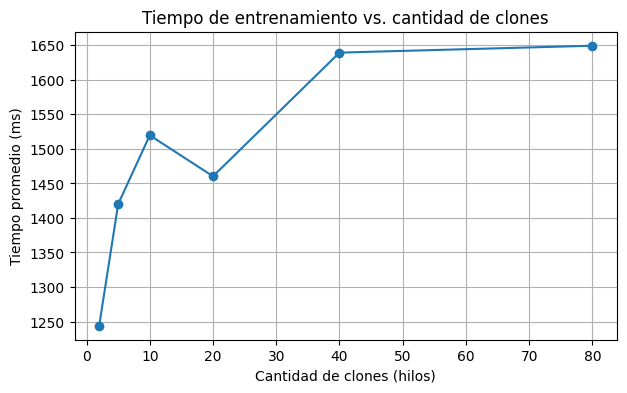

In [4]:
import subprocess
import re
import matplotlib.pyplot as plt

clone_counts = [2, 5, 10, 20, 40, 80]
repeats = 3
avg_times = []

for n in clone_counts:
    times = []
    for _ in range(repeats):
        out = subprocess.run(["./naruto_training", str(n)], capture_output=True, text=True).stdout
        m = re.search(r"Tiempo total: (\d+) ms", out)
        times.append(int(m.group(1)))
    avg = sum(times) / len(times)
    avg_times.append(avg)
    print(f"N={n}: tiempos={times} ms -> promedio={avg:.1f} ms")

plt.figure(figsize=(7, 4))
plt.plot(clone_counts, avg_times, marker="o")
plt.xlabel("Cantidad de clones (hilos)")
plt.ylabel("Tiempo promedio (ms)")
plt.title("Tiempo de entrenamiento vs. cantidad de clones")
plt.grid(True)
plt.show()

## Analisis

- **Cantidad optima de clones:** mirando el grafico, el tiempo total baja mientras la cantidad de clones es menor o similar a la cantidad de nucleos disponibles. Pasado ese punto, el tiempo deja de bajar y tiende a subir un poco, porque ya no hay nucleos libres para correr mas clones al mismo tiempo y empieza a pesar el overhead de crear hilos y el cambio de contexto entre ellos — agregar mas clones deja de ayudar (e incluso perjudica) una vez superada esa cantidad.
- **Nivel alcanzado:** al ser aleatorio (Chakra entre 5 y 10, 50% de probabilidad por intento), el nivel total de Naruto crece en promedio de forma proporcional a la cantidad de clones (mas clones = mas intentos en total = mas nivel esperado), sin importar cuanto tarde el entrenamiento.